In [2]:
from pathlib import Path
from collections import Counter
import random
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageDraw
import yaml

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

DATASET_ROOT = Path.cwd()
CONFIG_PATH = DATASET_ROOT / "data.yaml"

with open(CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg["names"]
NUM_CLASSES = int(cfg["nc"])


def resolve_split_images_dir(split_key: str, fallback_folder_name: str) -> Path:
    rel_path = cfg.get(split_key)
    candidates = []
    if rel_path is not None:
        candidates.extend(
            [
                (CONFIG_PATH.parent / rel_path).resolve(),
                (DATASET_ROOT / rel_path).resolve(),
            ]
        )
    candidates.append((DATASET_ROOT / fallback_folder_name / "images").resolve())

    for c in candidates:
        if c.exists():
            return c
    return candidates[-1]


SPLIT_DIRS = {
    "train": resolve_split_images_dir("train", "train"),
    "valid": resolve_split_images_dir("val", "valid"),
    "test": resolve_split_images_dir("test", "test"),
}

print(f"Dataset root: {DATASET_ROOT}")
print(f"Config path : {CONFIG_PATH}")
print(f"Classes     : {NUM_CLASSES}")
for split, path in SPLIT_DIRS.items():
    print(f"{split:>5}: {path}")

Dataset root: /Users/apple/Documents/ML/E-WASTE MACHINE LEARNING/e-waste
Config path : /Users/apple/Documents/ML/E-WASTE MACHINE LEARNING/e-waste/data.yaml
Classes     : 37
train: /Users/apple/Documents/ML/E-WASTE MACHINE LEARNING/e-waste/train/images
valid: /Users/apple/Documents/ML/E-WASTE MACHINE LEARNING/e-waste/valid/images
 test: /Users/apple/Documents/ML/E-WASTE MACHINE LEARNING/e-waste/test/images


In [3]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def image_key(p: Path) -> str:
    return p.name.rsplit(".", 1)[0]


def parse_yolo_label_line(line: str):
    parts = line.strip().split()
    if len(parts) != 5:
        return None, "invalid_format"
    try:
        class_id = int(float(parts[0]))
        x_c, y_c, w, h = map(float, parts[1:])
    except ValueError:
        return None, "non_numeric"

    if not (0 <= class_id < NUM_CLASSES):
        return None, "class_out_of_range"

    vals = [x_c, y_c, w, h]
    if not all(np.isfinite(vals)):
        return None, "non_finite"

    if w <= 0 or h <= 0:
        return None, "non_positive_wh"

    if not (0 <= x_c <= 1 and 0 <= y_c <= 1 and 0 < w <= 1 and 0 < h <= 1):
        return None, "normalized_out_of_range"

    rec = {
        "class_id": class_id,
        "class_name": CLASS_NAMES[class_id],
        "x_center": x_c,
        "y_center": y_c,
        "width": w,
        "height": h,
        "bbox_area_norm": w * h,
        "bbox_aspect_ratio": w / h,
    }
    return rec, None


image_records = []
label_records = []
issues = []
pairing_summary = []

for split, images_dir in SPLIT_DIRS.items():
    labels_dir = images_dir.parent / "labels"

    images = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]) if images_dir.exists() else []
    labels = sorted(labels_dir.glob("*.txt")) if labels_dir.exists() else []

    labels_by_key = {image_key(p): p for p in labels}
    images_by_key = {image_key(p): p for p in images}

    missing_labels = [k for k in images_by_key if k not in labels_by_key]
    orphan_labels = [k for k in labels_by_key if k not in images_by_key]

    pairing_summary.append(
        {
            "split": split,
            "images": len(images),
            "labels": len(labels),
            "images_missing_label": len(missing_labels),
            "orphan_label_files": len(orphan_labels),
        }
    )

    for k in missing_labels[:10]:
        issues.append({"split": split, "type": "missing_label", "image_key": k})
    for k in orphan_labels[:10]:
        issues.append({"split": split, "type": "orphan_label", "image_key": k})

    for img_path in images:
        k = image_key(img_path)
        label_path = labels_by_key.get(k)

        try:
            with Image.open(img_path) as im:
                width, height = im.size
                mode = im.mode
        except Exception as e:
            issues.append({"split": split, "type": "image_read_error", "image_key": k, "details": str(e)})
            continue

        n_objects = 0
        empty_label_file = False

        if label_path and label_path.exists():
            lines = label_path.read_text().strip().splitlines()
            if len(lines) == 0:
                empty_label_file = True

            for i, line in enumerate(lines, start=1):
                rec, err = parse_yolo_label_line(line)
                if err is not None:
                    issues.append(
                        {
                            "split": split,
                            "type": err,
                            "image_key": k,
                            "label_file": str(label_path.name),
                            "line_no": i,
                            "line": line,
                        }
                    )
                    continue

                rec.update(
                    {
                        "split": split,
                        "image_key": k,
                        "image_path": str(img_path),
                        "image_width": width,
                        "image_height": height,
                    }
                )
                label_records.append(rec)
                n_objects += 1

        image_records.append(
            {
                "split": split,
                "image_key": k,
                "image_path": str(img_path),
                "label_path": str(label_path) if label_path else None,
                "has_label_file": label_path is not None,
                "empty_label_file": empty_label_file,
                "image_width": width,
                "image_height": height,
                "image_mode": mode,
                "num_objects": n_objects,
                "image_area_px": width * height,
            }
        )

images_df = pd.DataFrame(image_records)
labels_df = pd.DataFrame(label_records)
issues_df = pd.DataFrame(issues)
pairing_df = pd.DataFrame(pairing_summary)

print("Pairing summary:")
display(pairing_df)
print(f"\nTotal images : {len(images_df):,}")
print(f"Total objects: {len(labels_df):,}")
print(f"Total issues : {len(issues_df):,}")

Pairing summary:


,split,images,labels,images_missing_label,orphan_label_files
0,train,4991,4991,0,0
1,valid,1444,1444,0,0
2,test,776,776,0,0



Total images : 7,211
Total objects: 5,470
Total issues : 2,630


In [5]:
# Re-parse labels with support for YOLO detection + segmentation formats

def parse_yolo_any_line(line: str):
    parts = line.strip().split()
    if len(parts) < 5:
        return None, "too_few_tokens"

    try:
        class_id = int(float(parts[0]))
        vals = list(map(float, parts[1:]))
    except ValueError:
        return None, "non_numeric"

    if not (0 <= class_id < NUM_CLASSES):
        return None, "class_out_of_range"
    if not np.all(np.isfinite(vals)):
        return None, "non_finite"

    # YOLO detection format: class x_center y_center width height
    if len(vals) == 4:
        x_c, y_c, w, h = vals
        if w <= 0 or h <= 0:
            return None, "non_positive_wh"
        if not (0 <= x_c <= 1 and 0 <= y_c <= 1 and 0 < w <= 1 and 0 < h <= 1):
            return None, "normalized_out_of_range"

    # YOLO segmentation format: class x1 y1 x2 y2 ...
    elif len(vals) >= 6 and len(vals) % 2 == 0:
        xs = np.array(vals[0::2])
        ys = np.array(vals[1::2])
        if not ((xs >= 0).all() and (xs <= 1).all() and (ys >= 0).all() and (ys <= 1).all()):
            return None, "normalized_out_of_range"

        x_min, x_max = float(xs.min()), float(xs.max())
        y_min, y_max = float(ys.min()), float(ys.max())
        w, h = x_max - x_min, y_max - y_min
        if w <= 0 or h <= 0:
            return None, "degenerate_polygon"
        x_c, y_c = (x_min + x_max) / 2.0, (y_min + y_max) / 2.0
    else:
        return None, "invalid_format"

    rec = {
        "class_id": class_id,
        "class_name": CLASS_NAMES[class_id],
        "x_center": x_c,
        "y_center": y_c,
        "width": w,
        "height": h,
        "bbox_area_norm": w * h,
        "bbox_aspect_ratio": w / h,
    }
    return rec, None


label_records = []
issues = []

for split, images_dir in SPLIT_DIRS.items():
    labels_dir = images_dir.parent / "labels"
    images = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]) if images_dir.exists() else []
    labels = sorted(labels_dir.glob("*.txt")) if labels_dir.exists() else []
    labels_by_key = {image_key(p): p for p in labels}

    for img_path in images:
        k = image_key(img_path)
        label_path = labels_by_key.get(k)
        if label_path is None:
            continue

        try:
            with Image.open(img_path) as im:
                width, height = im.size
        except Exception:
            continue

        lines = label_path.read_text().strip().splitlines()
        for i, line in enumerate(lines, start=1):
            rec, err = parse_yolo_any_line(line)
            if err:
                issues.append({
                    "split": split,
                    "type": err,
                    "image_key": k,
                    "label_file": label_path.name,
                    "line_no": i,
                    "line": line,
                })
            else:
                rec.update({
                    "split": split,
                    "image_key": k,
                    "image_path": str(img_path),
                    "image_width": width,
                    "image_height": height,
                })
                label_records.append(rec)

labels_df = pd.DataFrame(label_records)
issues_df = pd.DataFrame(issues)

print(f"After segmentation-aware parse -> objects: {len(labels_df):,}, issues: {len(issues_df):,}")
if len(issues_df):
    display(issues_df['type'].value_counts().head(10))

After segmentation-aware parse -> objects: 8,100, issues: 0


,split,images,images_with_objects,images_without_objects,total_objects,avg_objects_per_image,median_objects_per_image,empty_label_files,object_density
0,test,776,533,243,586,0.755155,1.0,0,0.755155
1,train,4991,3388,1603,3749,0.751152,1.0,0,0.751152
2,valid,1444,1018,426,1135,0.786011,1.0,0,0.786011


,class_id,class_name,instances
4,4,Coffee-Machine,288
31,31,Straight-Tube-Fluorescent-Lamp,268
0,0,Battery,250
25,25,Refrigerator,250
12,12,Electronic-Keyboard,249
36,36,Washing-Machine,242
33,33,TV-Remote-Control,240
10,10,Drone,234
29,29,Smartphone,233
19,19,Microwave,231


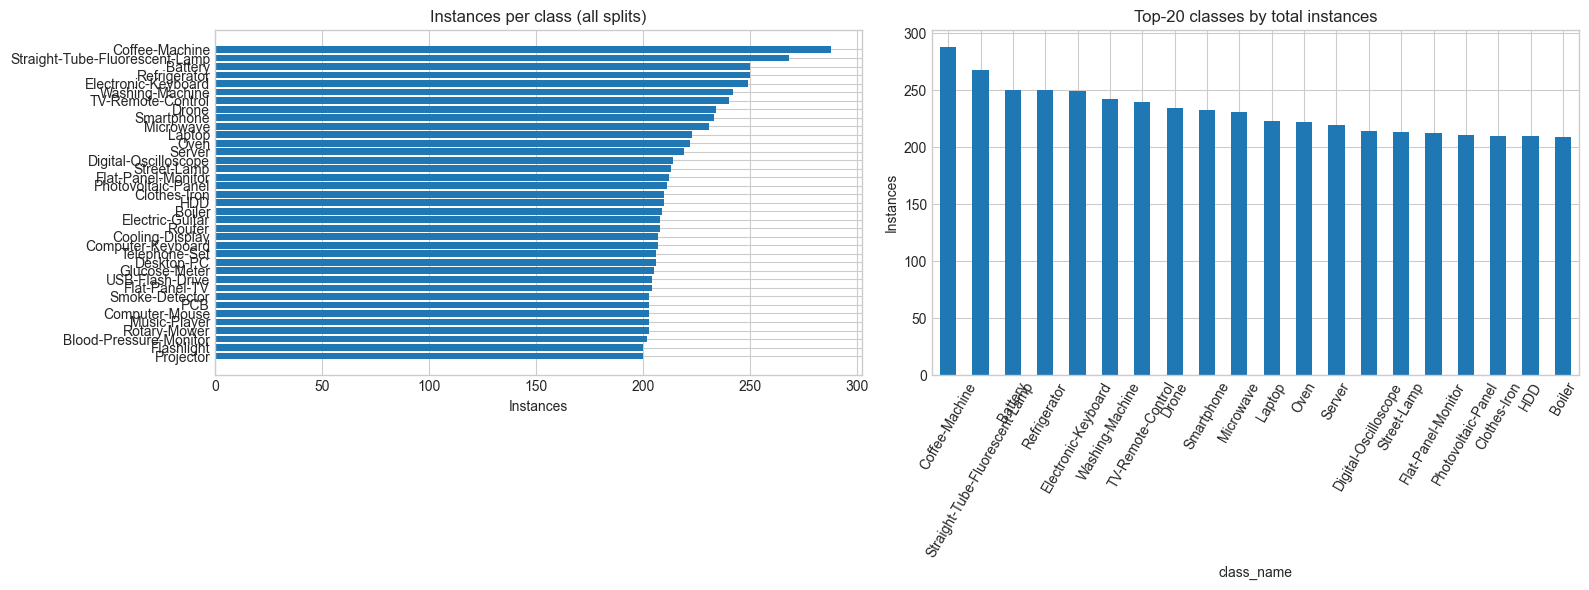

In [6]:
# 1) Split-level overview
split_overview = (
    images_df.groupby("split", as_index=False)
    .agg(
        images=("image_key", "count"),
        images_with_objects=("num_objects", lambda s: int((s > 0).sum())),
        images_without_objects=("num_objects", lambda s: int((s == 0).sum())),
        total_objects=("num_objects", "sum"),
        avg_objects_per_image=("num_objects", "mean"),
        median_objects_per_image=("num_objects", "median"),
        empty_label_files=("empty_label_file", "sum"),
    )
)
split_overview["object_density"] = split_overview["total_objects"] / split_overview["images"]
display(split_overview)

# 2) Class distribution
class_counts = (
    labels_df.groupby(["split", "class_id", "class_name"], as_index=False)
    .size()
    .rename(columns={"size": "instances"})
)
class_counts_total = (
    labels_df.groupby(["class_id", "class_name"], as_index=False)
    .size()
    .rename(columns={"size": "instances"})
    .sort_values("instances", ascending=False)
)

display(class_counts_total.head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(class_counts_total["class_name"], class_counts_total["instances"])
axes[0].invert_yaxis()
axes[0].set_title("Instances per class (all splits)")
axes[0].set_xlabel("Instances")

pivot_split_class = class_counts.pivot_table(index="class_name", columns="split", values="instances", fill_value=0)
(pivot_split_class.sum(axis=1).sort_values(ascending=False).head(20)
 .plot(kind="bar", ax=axes[1], title="Top-20 classes by total instances"))
axes[1].set_ylabel("Instances")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

,bbox_area_norm,bbox_aspect_ratio,x_center,y_center
count,8100.000000,8100.000000,8100.000000,8100.000000
mean,0.328770,1.198370,0.497947,0.504552
std,0.231928,0.917867,0.124984,0.102897
min,0.000088,0.074310,0.037984,0.040625
1%,0.003681,0.192299,0.135937,0.206234
5%,0.022667,0.315975,0.265625,0.337500
25%,0.140683,0.634119,0.467187,0.470313
50%,0.293093,1.012097,0.500000,0.500000
75%,0.473014,1.484999,0.528125,0.535937
95%,0.765166,2.781296,0.732383,0.696875


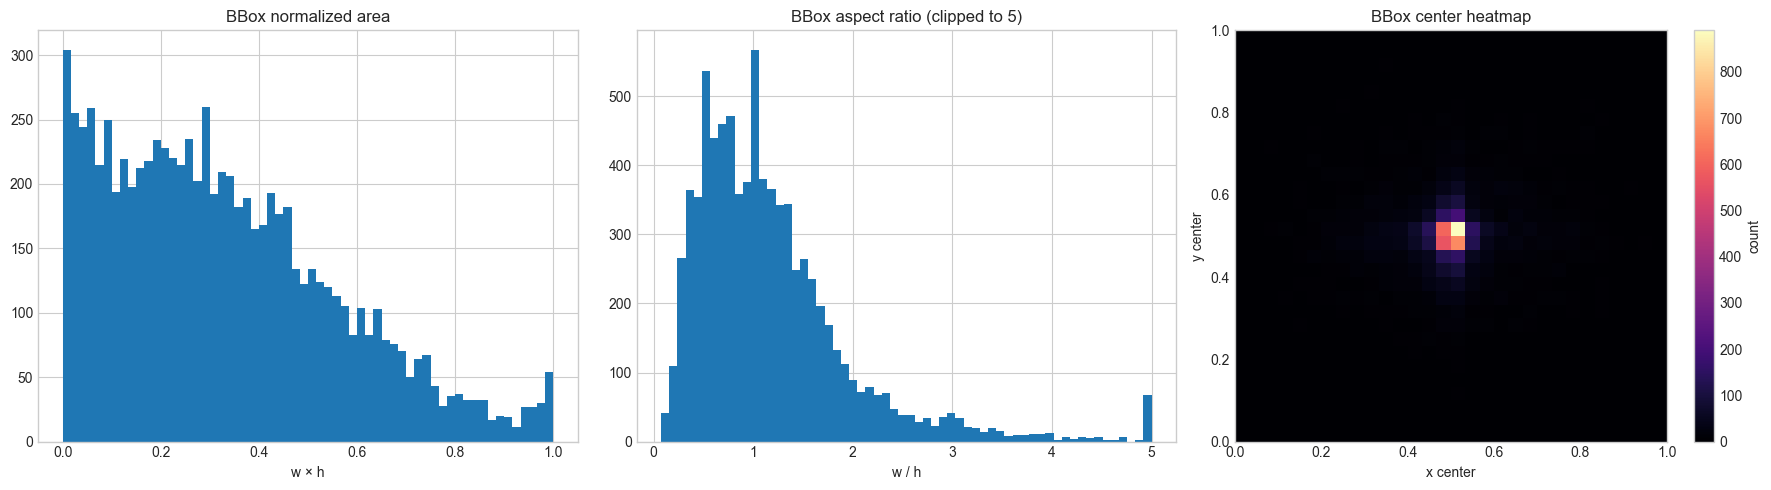

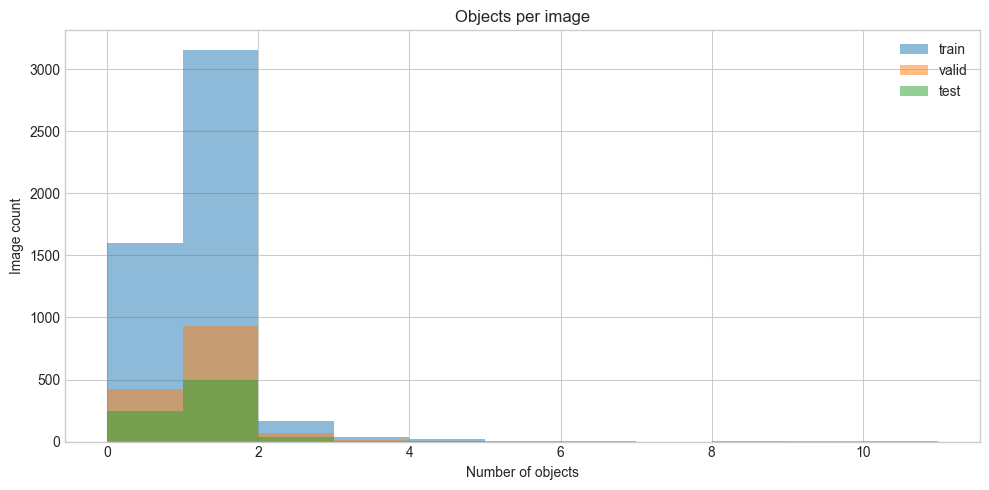

In [7]:
# BBox geometry EDA
bbox_stats = labels_df[["bbox_area_norm", "bbox_aspect_ratio", "x_center", "y_center"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
display(bbox_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(labels_df["bbox_area_norm"], bins=60)
axes[0].set_title("BBox normalized area")
axes[0].set_xlabel("w × h")

aspect = labels_df["bbox_aspect_ratio"].clip(lower=0, upper=5)
axes[1].hist(aspect, bins=60)
axes[1].set_title("BBox aspect ratio (clipped to 5)")
axes[1].set_xlabel("w / h")

h = axes[2].hist2d(labels_df["x_center"], labels_df["y_center"], bins=30, range=[[0, 1], [0, 1]], cmap="magma")
axes[2].set_title("BBox center heatmap")
axes[2].set_xlabel("x center")
axes[2].set_ylabel("y center")
plt.colorbar(h[3], ax=axes[2], label="count")

plt.tight_layout()
plt.show()

# Objects per image by split
fig, ax = plt.subplots(figsize=(10, 5))
for split in ["train", "valid", "test"]:
    vals = images_df.loc[images_df["split"] == split, "num_objects"]
    ax.hist(vals, bins=range(0, int(vals.max()) + 2), alpha=0.5, label=split)
ax.set_title("Objects per image")
ax.set_xlabel("Number of objects")
ax.set_ylabel("Image count")
ax.legend()
plt.tight_layout()
plt.show()

,resolution,count
0,640x640,7211


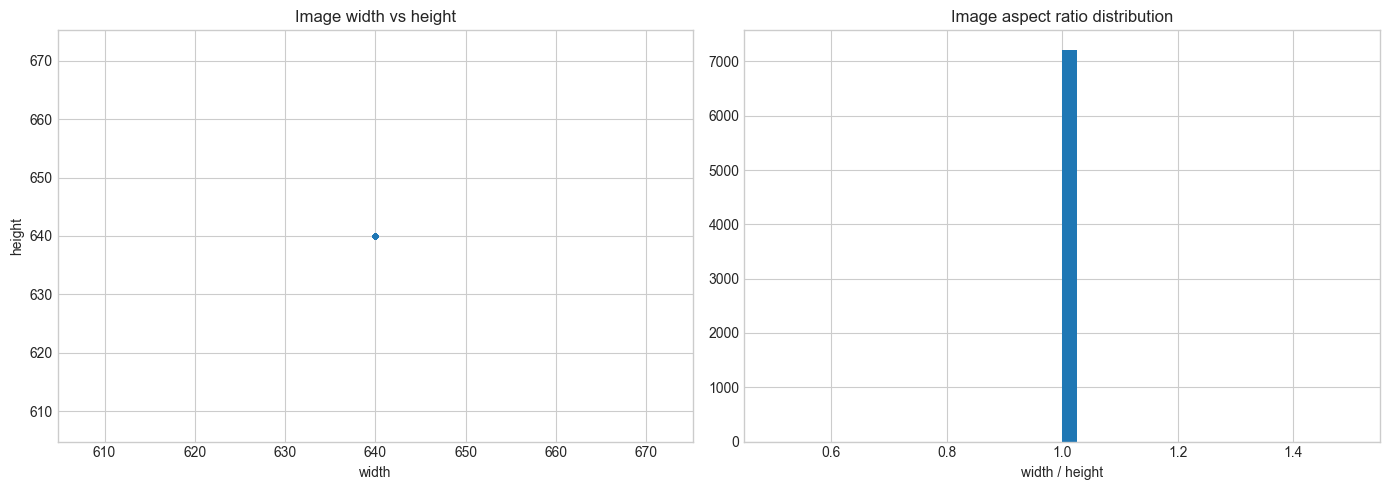

No parsing/pairing issues detected ✅
Exact duplicate groups: 130


,image_path,md5
1731,/Users/apple/Documents/ML/E-WASTE MACHINE LEAR...,0049441c5a5fd1008cf50d4352f26729
5469,/Users/apple/Documents/ML/E-WASTE MACHINE LEAR...,0049441c5a5fd1008cf50d4352f26729


In [8]:
# Image-level EDA
images_df["aspect_ratio"] = images_df["image_width"] / images_df["image_height"]

resolution_counts = (
    images_df.assign(resolution=images_df["image_width"].astype(str) + "x" + images_df["image_height"].astype(str))
    .groupby("resolution", as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values("count", ascending=False)
)

display(resolution_counts.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(images_df["image_width"], images_df["image_height"], s=8, alpha=0.4)
axes[0].set_title("Image width vs height")
axes[0].set_xlabel("width")
axes[0].set_ylabel("height")

axes[1].hist(images_df["aspect_ratio"], bins=40)
axes[1].set_title("Image aspect ratio distribution")
axes[1].set_xlabel("width / height")

plt.tight_layout()
plt.show()

# Annotation/data quality issues
if len(issues_df) == 0:
    print("No parsing/pairing issues detected ✅")
else:
    issue_counts = issues_df.groupby(["split", "type"], as_index=False).size().rename(columns={"size": "count"})
    display(issue_counts.sort_values(["split", "count"], ascending=[True, False]))
    display(issues_df.head(20))

# Quick exact-duplicate check by md5 hash
hash_rows = []
for p in images_df["image_path"]:
    try:
        with open(p, "rb") as f:
            digest = hashlib.md5(f.read()).hexdigest()
        hash_rows.append((p, digest))
    except Exception:
        pass

hash_df = pd.DataFrame(hash_rows, columns=["image_path", "md5"])
dup_groups = hash_df.groupby("md5").size().reset_index(name="count")
exact_dups = dup_groups[dup_groups["count"] > 1].sort_values("count", ascending=False)

print(f"Exact duplicate groups: {len(exact_dups)}")
if len(exact_dups):
    sample_dup_hash = exact_dups.iloc[0]["md5"]
    display(hash_df[hash_df["md5"] == sample_dup_hash].head(10))

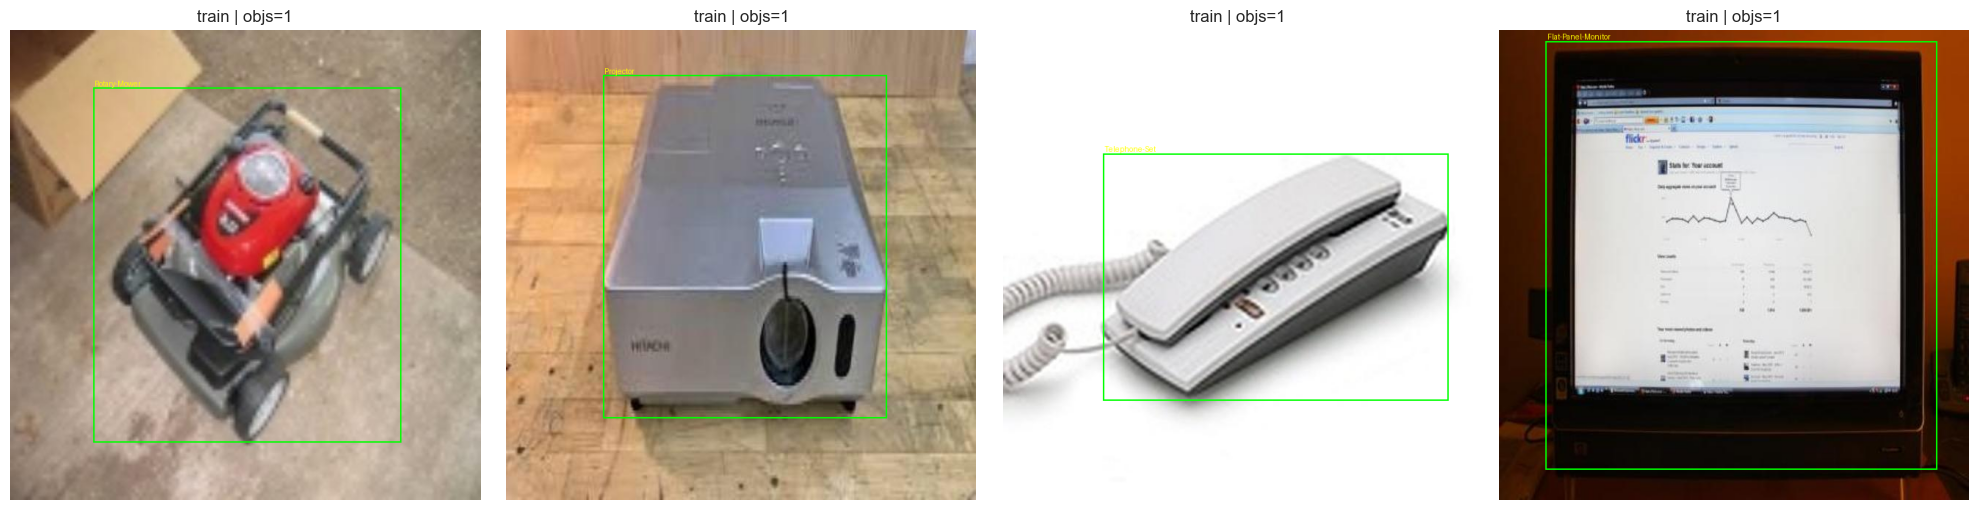

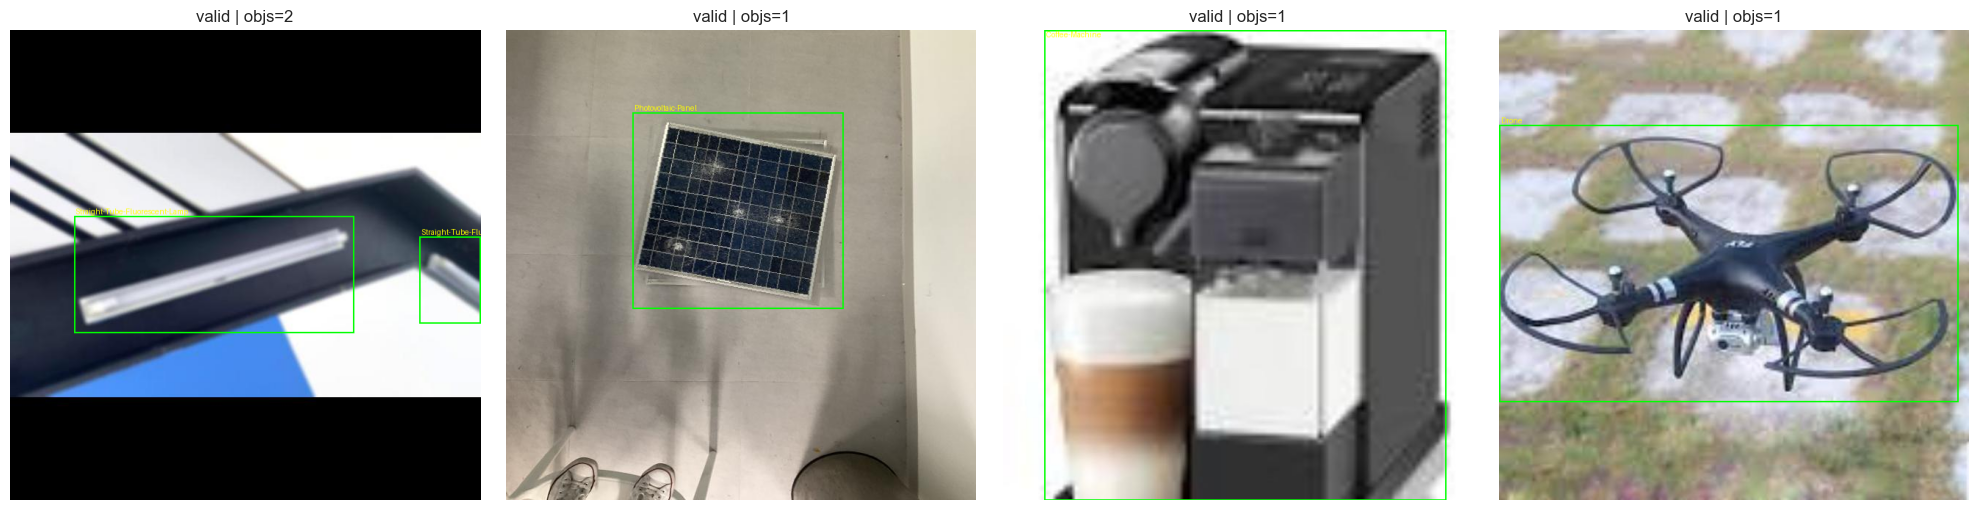

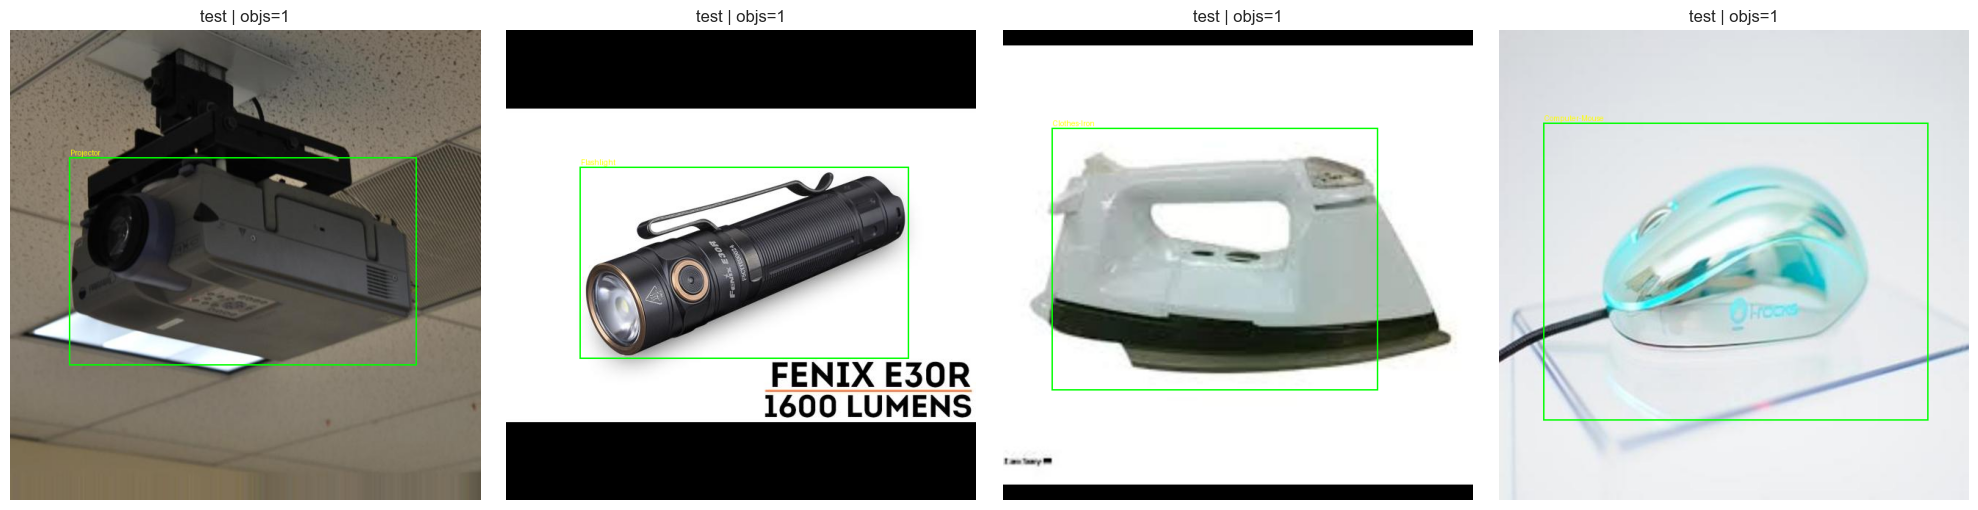

In [9]:
# Visual sanity-check: random annotated samples per split

def draw_boxes_on_image(img_path: Path, label_rows: pd.DataFrame, max_boxes: int = 30):
    with Image.open(img_path) as im:
        im = ImageOps.exif_transpose(im).convert("RGB")
        draw = ImageDraw.Draw(im)
        w, h = im.size

        for _, r in label_rows.head(max_boxes).iterrows():
            xc, yc, bw, bh = r["x_center"], r["y_center"], r["width"], r["height"]
            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            x2 = (xc + bw / 2) * w
            y2 = (yc + bh / 2) * h
            draw.rectangle([x1, y1, x2, y2], outline="lime", width=2)
            draw.text((x1 + 2, max(0, y1 - 12)), r["class_name"], fill="yellow")

    return np.array(im)


for split in ["train", "valid", "test"]:
    subset = images_df[(images_df["split"] == split) & (images_df["num_objects"] > 0)]
    if subset.empty:
        continue

    n = min(4, len(subset))
    sample_paths = random.sample(subset["image_path"].tolist(), k=n)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, img_path_str in zip(axes, sample_paths):
        img_path = Path(img_path_str)
        key = image_key(img_path)
        rows = labels_df[(labels_df["split"] == split) & (labels_df["image_key"] == key)]
        rendered = draw_boxes_on_image(img_path, rows)
        ax.imshow(rendered)
        ax.set_title(f"{split} | objs={len(rows)}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [10]:
# Auto-generated EDA highlights
n_images = len(images_df)
n_objects = len(labels_df)

class_imbalance_ratio = class_counts_total["instances"].max() / class_counts_total["instances"].min()

highlights = {
    "num_images": n_images,
    "num_objects": n_objects,
    "num_classes": NUM_CLASSES,
    "avg_objects_per_image": round(images_df["num_objects"].mean(), 3),
    "median_objects_per_image": float(images_df["num_objects"].median()),
    "images_without_objects": int((images_df["num_objects"] == 0).sum()),
    "small_bbox_share_(area<0.02)": round(float((labels_df["bbox_area_norm"] < 0.02).mean()), 4),
    "very_large_bbox_share_(area>0.5)": round(float((labels_df["bbox_area_norm"] > 0.5).mean()), 4),
    "class_imbalance_ratio_max/min": round(float(class_imbalance_ratio), 3),
}

print("EDA highlights:")
for k, v in highlights.items():
    print(f"- {k}: {v}")

EDA highlights:
- num_images: 7211
- num_objects: 8100
- num_classes: 37
- avg_objects_per_image: 0.759
- median_objects_per_image: 1.0
- images_without_objects: 2272
- small_bbox_share_(area<0.02): 0.0451
- very_large_bbox_share_(area>0.5): 0.2246
- class_imbalance_ratio_max/min: 1.44
